# Лабораторная работа 4

# Правильный многоугольник Рело. Векторизация вычислений в `numpy`

Лобацевич Владислав Игоревич, $03.04.2026$

## Основные определения
**Треугольник Рело** представляет собой область пересечения трех кругов радуса $r$ с центрами в вершинах равностороннего треугольника с длиной стороны $r$.

**Правильный $n$-угольник Рело** представляет собой область пересечения $n$ кругов радуса $r$ с центрами в вершинах правильного $n$-угольника с **нечётным числом** сторон длины $l$. Радиус круга $r$ согласован с длиной стороны $l$ правильного многоугольника таким образом, чтобы окружность радиуса $r$ с центром в вершине правильного $n$-угольника проходила через две соседние вершины правильного $n$-угольника, противолежащие центру.

**Опорные прямые фигуры** — это две параллельные прямые, которые касаются фигуры, но не пересекают ее.

**Фигура постоянной ширины** — это геометрическая фигура, для которой расстояние между любыми опорными прямыми будет всегда одинаковым. Расстояние между опорными прямыми называется **шириной фигуры**.

*Примерами фигур* постоянной ширины являются *правильный многоугольник Рело* и
*круг*. Ширина правильного многоугольника Рело равна радиусу $r$ пересекающихся кругов. Ширина круга равна диаметру круга. Среди всех фигур постоянной ширины треугольник Рело имеет наименьшую площадь, круг имеет наибольшую площадь.

## Задание 4.1. Построение треугольника Рело

Подключим модули

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Определим переменные

In [3]:
n = 3
center = np.array([0, 0])
r = 10.
N = 100

### Этап 1. Вычисление координат вершин правильного треугольника
Вершины правильного многоугольника расположены на окружности, описанной вокруг многоугольника. Радиус $R$ окружности, описанной вокруг правильного $n$-угольника с длиной стороны $l$, вычисляется по формуле
$$R = \frac{l}{2\sin\frac{\pi}{n}}.$$
Длина стороны $l$ правильного треугольника, на котором будем строить треугольник Рело, совпадает с шириной треугольника Рело $r$.

In [4]:
l = r

Вычислим радиус описанной окружности $R$

In [5]:
R = l / (2 * np.sin(np.pi / n))

Зафиксируем прямоугольную декартову систему координат. Центр треугольника размещаем в точке `center`. Построим матрицу `vertices` с координатами вершин правильного треугольника, используя параметрическое описание точек описанной окружности по формуле $x(t) = x_0 +R\cos(t), y(t) = y_0 +R\sin(t)$ для значений $t \in \{0,\frac{2\pi}{3},\frac{4\pi}{3}\}$.

In [6]:
t = np.arange(0, 2 * np.pi, 2 * np.pi / n)

vertices = center + R * np.transpose([np.cos(t), np.sin(t)])
vertices

array([[ 5.77350269,  0.        ],
       [-2.88675135,  5.        ],
       [-2.88675135, -5.        ]])

**Обратим внимание**, что массив `vertices` вычислен без явного использования циклов. Он построен за счет итерационного прохода по элементам массива `t`. Приведённый код является иллюстрацией векторизации вычислений в `numpy`.

$\color{red}\text{Оформим}$ последовательность вычислений для выражения 
`vertices = center + R * np.transpose([np.cos(t), np.sin(t)])`:

- Вычисление двух массивов – `np.cos(t)` и `np.sin(t)` создают отдельные одномерные массивы значений косинуса и синуса для всех углов $t$.

- Объединение в список – `[np.cos(t), np.sin(t)]` образует список из двух массивов.

- Транспонирование с помощью `np.transpose(...)` превращает список в двумерный массив формы $(3, 2)$, где каждая строка — пара `(cos, sin)` для одного угла.

- Умножение на $R$ поэлементно увеличивает координаты точек до радиуса $R$.

- Прибавление `center` переносит точки из начала координат в заданный центр описанной окружности.

Для доступа к элементам матрицы в `numpy` можно использовать индексацию с двумя индексами

In [7]:
vertices[0, 0], vertices[0,:], vertices[:, 1]

(np.float64(5.773502691896258),
 array([5.77350269, 0.        ]),
 array([ 0.,  5., -5.]))

Построим изображение вершин треугольника

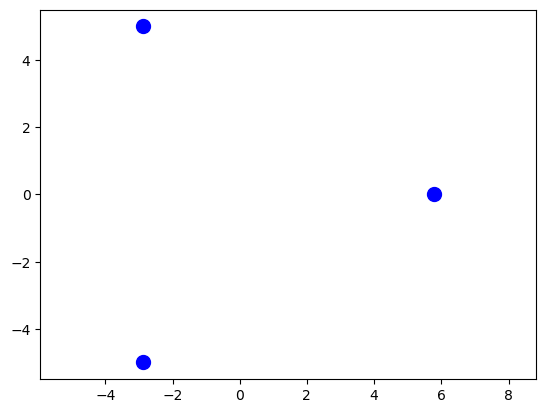

In [8]:
plt.plot(vertices[:, 0], vertices[:, 1], 'b.', markersize=20)
plt.axis('equal');

### Этап 2. Представление одной стороны треугольника Рело

Обозначим через $\alpha$ центральный угол, соответствующий стороне правильного $n$-угольника. Тогда
$$\alpha = \frac{2 \pi}{n}.$$
Обозначим через $\beta$ центральный угол, соответствующий стороне правильного многоугольника Рело, когда центр окружности расположен в вершине правильного многоугольника. Тогда
$$\beta = \frac{\alpha}{2}.$$
Необходимо построить матрицу с координатами точек, описывающих одну сторону треугольника Рело относительно вершины `vertices[0]`. Сторона представляет собой дугу окружности радиуса $r$ с центром в точке `vertices[0]` и значением угла $[\pi - \frac{\beta}{2}, \pi + \frac{\beta}{2}].$

Вычислим значение введённых величин $\alpha$ и $\beta$

In [13]:
alpha = 2 * np.pi / n
beta = alpha / 2

Вычислим массив `angle` значений угла для построения координат точек стороны треугольника Рело, состоящий из `N` элементов

In [14]:
angle = np.linspace(-beta / 2, beta / 2, N)

Вычислим матрицу `side0` с координатами точек первой стороны треугольника Рело, используя параметрическое описание окружности с центром в точке `vertices[0]` радиусом `r` для значений угла на отрезке $[\pi - \frac{\beta}{2}, \pi + \frac{\beta}{2}]$.

In [16]:
side0 = vertices[0] + r * np.transpose([
    np.cos(np.pi + angle),
    np.sin(np.pi + angle)
])

**Обратим внимание**, что массив `side0` вычислен без явного использование циклов. Он построен за счёт итерационного прохода по элементам массива `angle`. 
Приведённый код является иллюстрацией векторизации вычислений в `numpy`.

$\color{red}\text{Приведём}$ формулы для параметрического описания точек стороны треугольника Рело.

Координаты точек дуги задаются так:
$$\begin{cases}
x(\theta) = x_0 + r \cdot \cos(\theta) \\[4pt]
y(\theta) = y_0 + r \cdot \sin(\theta)
\end{cases}, 
\quad \theta \in [\pi - \frac{\beta}{2},\pi + \frac{\beta}{2}]$$

И в нашем коде мы делаем замену $\theta = \pi + \varphi$:
$$\begin{cases}
x(\varphi) = x_0 + r \cdot \cos(\pi + \varphi) = x_0 - r \cdot \cos\varphi \\[4pt]
y(\varphi) = y_0 + r \cdot \sin(\pi + \varphi) = y_0 - r \cdot \sin\varphi
\end{cases}, 
\quad \varphi \in [- \frac{\beta}{2},\frac{\beta}{2}]$$

Построим изображение вершин и стороны треугольника Рело

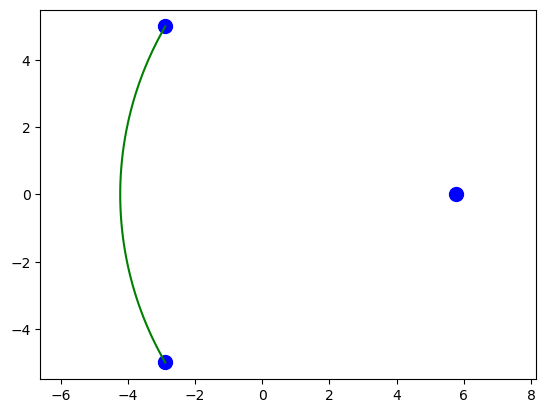

In [17]:
plt.plot(vertices[:, 0], vertices[:, 1], "b.", markersize=20)
plt.plot(side0[:, 0], side0[:, 1], "g-", markersize=20)
plt.axis("equal");

Вычислим матрицу `side1` с координатами точек, описывающих сторону треугольника Рело от носительно второй вершины `vertices[1]`. Сторона представляет собой дугу окружности радиуса $r$ с центром в точке `vertices[1]` и значением угла $[\pi - \frac{\beta}{2} + \alpha, \pi + \frac{\beta}{2} + \alpha]$

In [18]:
side1 = vertices[1] + r * np.transpose([
    np.cos(np.pi + angle + alpha),
    np.sin(np.pi + angle + alpha)
])

Построим изображение вершин и двух сторон треугольника Рело

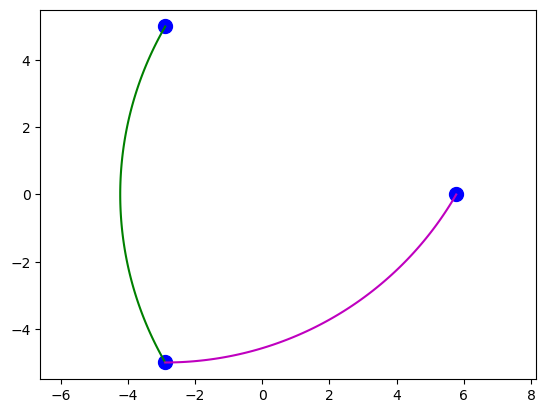

In [21]:
plt.plot(vertices[:, 0], vertices[:, 1], "b.", markersize=20)
plt.plot(side0[:, 0], side0[:, 1], "g-", markersize=20)
plt.plot(side1[:, 0], side1[:, 1], "m-", markersize=20)
plt.axis("equal");

### Этап 3. Моделирование границы треугольника Рело
Создадим *список* из матриц, каждая из которых содержит координаты точек одной из сторон треугольника Рело

In [22]:
list_sides = [vertices[i] + r * np.transpose([
    np.cos(np.pi + angle + i * alpha),
    np.sin(np.pi + angle + i * alpha)
]) for i in range(n)]

С помощью функции `concatenate` из расширения `numpy` объединим массивы, созданные для каждой из сторон треугольника Рело, в единый массив `sides`

In [23]:
sides = np.concatenate(list_sides)

Построим изображение вершин и всех сторон треугольника Рело

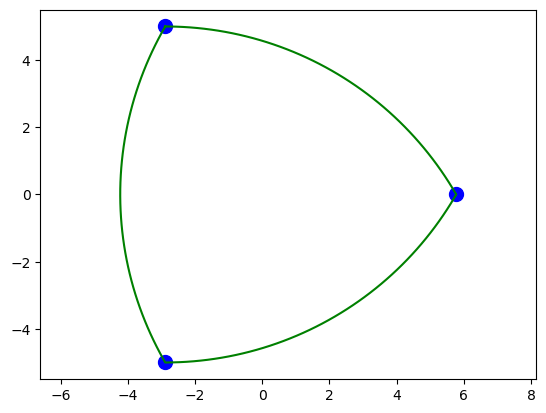

In [25]:
plt.plot(vertices[:, 0], vertices[:, 1], "b.", markersize=20)
plt.plot(sides[:, 0], sides[:, 1], "g-", markersize=20)
plt.axis("equal");

## Задание 4.2. Построение правильного многоугольника Рело

 Центральный угол $$\alpha = \frac{2\pi}{n} \quad \beta = \frac{\alpha}{2}$$
 Радиус $r$ — это расстояние между вершинами через одну, $r$ — хорда окружности радиуса $R$

Тогда длина стороны многоугольника $$l = 2R\sin\frac{\pi}{n}$$ 
А радиус Рело: $$r = 2R\sin\frac{(n-1)\pi}{2n}$$

Выразим $R$:
$$R = \frac{r}{2\sin\frac{(n-1)\pi}{2n}}$$
Подставим в формулу $l$:
$$l = 2\frac{r}{2\sin\frac{(n-1)\pi}{2n}}\sin\frac{\pi}{n}$$
Итог: $$l = r\frac{\sin\frac{\pi}{n}}{\sin\frac{(n-1)\pi}{2n}}$$ 

Начнём с объявления данных:

In [43]:
n = 3
center = np.array([1, 1])
r = 5.
N = 200

Перейдём к реализации:

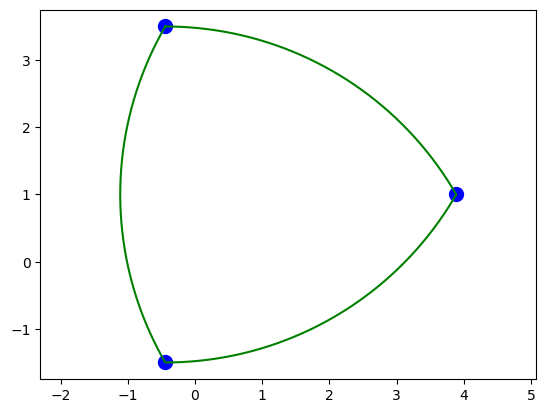

In [48]:
l = r * np.sin(np.pi / n) / np.sin((n - 1) * np.pi / (2 * n))
R = l / (2 * np.sin(np.pi / n))

t = np.arange(0, 2 * np.pi, 2 * np.pi / n)
vertices = center + R * np.transpose([np.cos(t), np.sin(t)])

alpha = 2 * np.pi / n
beta = alpha / 2
angle = np.linspace(-beta / 2, beta / 2, N)

list_sides = [vertices[i] + r * np.transpose([
    np.cos(np.pi + angle + i * alpha),
    np.sin(np.pi + angle + i * alpha)
]) for i in range(n)]

sides = np.concatenate(list_sides)

plt.plot(vertices[:, 0], vertices[:, 1], "b.", markersize=20)
plt.plot(sides[:, 0], sides[:, 1], "g-", markersize=20)
plt.axis("equal");

## Задание 4.3. Результирующая пользовательская функция

а) $\color{red}\text{Напишем}$ пользовательскую функцию `regular_polygon_Relo(n, center, r, N)` на основании кода из прошлого задания:

б) $\color{red}\text{Осуществим}$ контроль за значениями аргументов при вызове функции с помощью оператора `assert`

в) $\color{red}\text{Укажем}$ аннотации типов и $\color{red}\text{оформим}$ строки документации. $\color{red}\text{Осуществим}$ доступ к аннотации типов и к строкам документации через атрибуты объекта функции.

г) $\color{red}\text{Создадим}$ модуль relo.py, в котором будет содержаться наша функция `regular_polygon_Relo`.

In [107]:
def regular_polygon_Relo(
    n: int = 3,
    center: np.ndarray = np.array([0, 0]), 
    r: float = 1., 
    N: int = 100
) -> np.ndarray:
    """Вычисляет координаты точек границы правильного многоугольника Рело.

    Arguments :
    n: НЕЧЁТНОЕ число вершин
    center: координаты центра
    r: радиус фигуры
    N: количество точек на одной стороне
    
    Returns : Массив формы (n * N, 2)
    """

    assert isinstance(n, int), "n должно быть ЦЕЛЫМ ЧИСЛОМ"
    assert n % 2 == 1, "n должно быть НЕЧЁТНЫМ числом"
    assert n > 2, "n должно быть ОТ ТРЁХ и более"

    assert isinstance(r, (int, float)), "r должен быть ЧИСЛОМ"
    assert r > 0, "r должен быть ПОЛОЖИТЕЛЬНЫМ"

    assert isinstance(N, int), "N должно быть ЦЕЛЫМ числом"
    assert N > 0, "N должно быть НАТУРАЛЬНЫМ"

    assert isinstance(center, np.ndarray), "center должен быть numpy-массивом"
    assert center.shape == (2,), "center должен иметь размер 2"


    l = r * np.sin(np.pi / n) / np.sin((n - 1) * np.pi / (2 * n))
    R = l / (2 * np.sin(np.pi / n))
    
    t = np.arange(0, 2 * np.pi, 2 * np.pi / n)
    vertices = center + R * np.transpose([np.cos(t), np.sin(t)])
    
    alpha = 2 * np.pi / n
    beta = alpha / 2
    angle = np.linspace(-beta / 2, beta / 2, N)
    
    list_sides = [vertices[i] + r * np.transpose([
        np.cos(np.pi + angle + i * alpha),
        np.sin(np.pi + angle + i * alpha)
    ]) for i in range(n)]
    
    sides = np.concatenate(list_sides)

    return sides

Проверим работоспособность нашей функции:

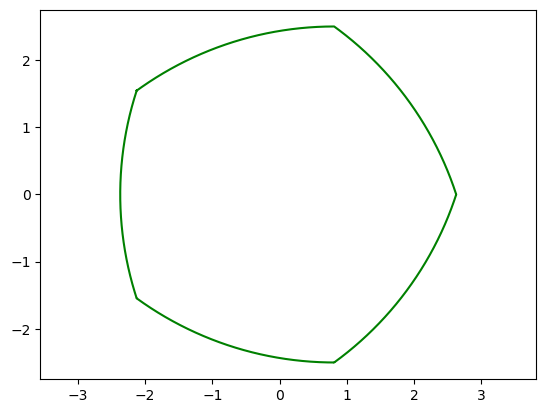

In [108]:
sides = regular_polygon_Relo(n=5, r=5)

plt.plot(sides[:, 0], sides[:, 1], 'g-')
plt.axis("equal");

$\color{red}\text{Проверим}$ аннотации и документацию:

In [109]:
print(regular_polygon_Relo.__annotations__)
print(regular_polygon_Relo.__doc__)

{'n': <class 'int'>, 'center': <class 'numpy.ndarray'>, 'r': <class 'float'>, 'N': <class 'int'>, 'return': <class 'numpy.ndarray'>}
Вычисляет координаты точек границы правильного многоугольника Рело.

Arguments :
n: НЕЧЁТНОЕ число вершин
center: координаты центра
r: радиус фигуры
N: количество точек на одной стороне

Returns : Массив формы (n * N, 2)



$\color{red}\text{Проверим}$ контроль за значениями аргументов через `assert`:

In [110]:
regular_polygon_Relo(n=2)

AssertionError: n должно быть НЕЧЁТНЫМ числом

In [111]:
regular_polygon_Relo(n=3, center=[0, 0])

AssertionError: center должен быть numpy-массивом

$\color{red}\text{Протестируем}$ наш модуль `relo`:

In [112]:
import relo

print(relo.regular_polygon_Relo.__annotations__)
print(relo.regular_polygon_Relo.__doc__)

{'n': <class 'int'>, 'center': <class 'numpy.ndarray'>, 'r': <class 'float'>, 'N': <class 'int'>, 'return': <class 'numpy.ndarray'>}
Вычисляет координаты точек границы правильного многоугольника Рело.

Arguments :
n: НЕЧЁТНОЕ число вершин
center: координаты центра
r: радиус фигуры
N: количество точек на одной стороне

Returns : Массив формы (n * N, 2)



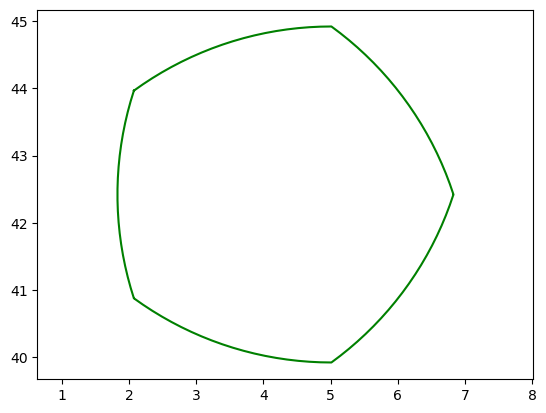

In [113]:
sides = relo.regular_polygon_Relo(5, np.array([4.2, 42.42]), 5, 20)

plt.plot(sides[:, 0], sides[:, 1], 'g-')
plt.axis("equal");

## Задание 4.4. Тестирование пользовательской функции

Для начала перезагрузим наш модуль и очистим ядро пайтона

In [125]:
import importlib, relo
importlib.reload(relo);
%reset -f

а) $\color{red}\text{Протестируем}$ функцию `regular_polygon_Relo` из нашего модуля `relo` для разных значений аргументов:

In [127]:
import relo

try:
    relo.regular_polygon_Relo(n='5')
except AssertionError as e:
    print(e)

try:
    relo.regular_polygon_Relo(n=1)
except AssertionError as e:
    print(e)

try:
    relo.regular_polygon_Relo(N=4.2)
except AssertionError as e:
    print(e)

try:
    relo.regular_polygon_Relo(N=-4)
except AssertionError as e:
    print(e)

try:
    relo.regular_polygon_Relo(r=0)
except AssertionError as e:
    print(e)

n должно быть ЦЕЛЫМ ЧИСЛОМ
n должно быть ОТ ТРЁХ и более
N должно быть ЦЕЛЫМ числом
N должно быть НАТУРАЛЬНЫМ
r должен быть ПОЛОЖИТЕЛЬНЫМ


б) Ну и $\color{red}\text{построим}$  в одной системе координат правильные многоугольники Рело для различных значений вершин `n`, положений центра `center`, ширины `r` и количества точек для представления одной стороны `N`. ($\color{red}\text{Вызовем}$ функцию разными способами)

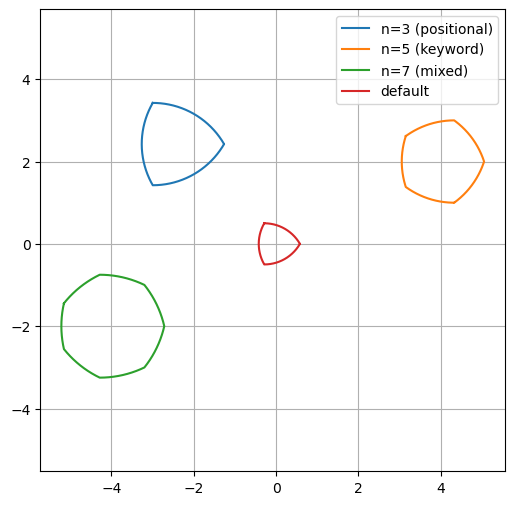

In [136]:
import matplotlib.pyplot as plt
import numpy as np
from relo import regular_polygon_Relo

plt.figure(figsize=(6,6))

pts1 = regular_polygon_Relo(3, np.array([-2.42, 2.4242]), 2, 100)
pts2 = regular_polygon_Relo(n=5, center=np.array([4, 2]), r=2, N=150)
pts3 = regular_polygon_Relo(7, r=2.5, center=np.array([-4, -2]), N=120)
pts4 = regular_polygon_Relo()

plt.plot(pts1[:, 0], pts1[:, 1], label="n=3 (positional)")
plt.plot(pts2[:, 0], pts2[:, 1], label="n=5 (keyword)")
plt.plot(pts3[:, 0], pts3[:, 1], label="n=7 (mixed)")
plt.plot(pts4[:, 0], pts4[:, 1], label="default")

plt.legend()
plt.axis('equal')
plt.grid()

plt.show()

# КОНЕЦ ЛАБЫ!